In [1]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Clean, minimal dark theme for presentation visuals
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


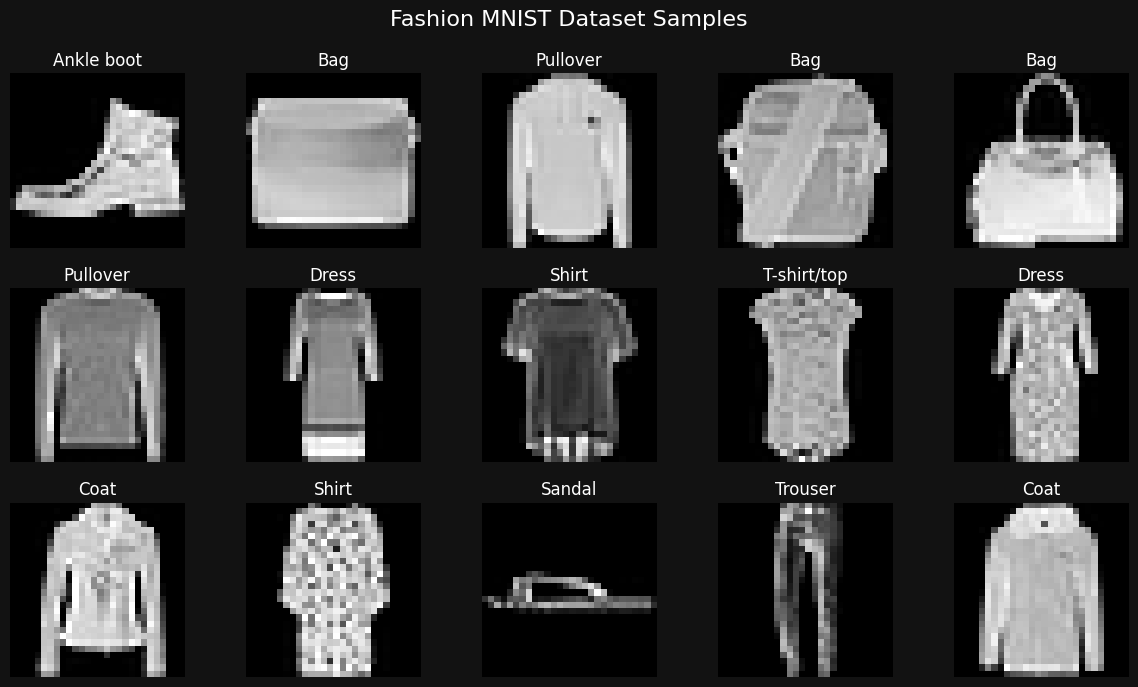


Feature Extraction Note for Slide 2:
In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.


In [2]:
# ==========================================
# 1. DATASET & VISUALIZATION
# ==========================================
# Load Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_ds = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

classes = train_ds.classes

# Generate a grid of examples for your presentation slide
def show_dataset_examples():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 5, figsize=(12, 7))
    fig.suptitle('Fashion MNIST Dataset Samples', fontsize=16, color='white')
    for i, ax in enumerate(axes.flat):
        img = images[i].numpy().squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[i]], color='white')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_dataset_examples()

print("\nFeature Extraction Note for Slide 2:")
print("In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.")

In [3]:
# ==========================================
# 2. METHODS & HYPERPARAMETER TUNING
# ==========================================
# Define the CNN Architecture
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Function to run the tuning experiment
def run_experiments(learning_rates=[0.01, 0.001], epochs=4):
    results = []
    best_model_state = None
    best_acc = 0

    for lr in learning_rates:
        print(f"\nTraining CNN with Learning Rate: {lr}...")
        model = FashionCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        history = {'train_loss': [], 'val_acc': []}

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            # Validation phase
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(train_loader)
            epoch_acc = correct / total
            history['train_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc)
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Val Acc: {epoch_acc:.4f}")

        final_acc = history['val_acc'][-1]
        results.append({'LR': lr, 'Final_Accuracy': final_acc, 'History': history})

        # Save the best model for the confusion matrix later
        if final_acc > best_acc:
            best_acc = final_acc
            best_model_state = model.state_dict()

    # Load best weights into a final model object
    best_model = FashionCNN().to(device)
    best_model.load_state_dict(best_model_state)

    return results, best_model

# Execute the tuning loop (This will take a minute or two to run)
tuning_results, best_model = run_experiments(learning_rates=[0.01, 0.001], epochs=4)


Training CNN with Learning Rate: 0.01...
  Epoch 1/4 - Loss: 0.4781, Val Acc: 0.8733
  Epoch 2/4 - Loss: 0.3454, Val Acc: 0.8816
  Epoch 3/4 - Loss: 0.3230, Val Acc: 0.8845
  Epoch 4/4 - Loss: 0.3111, Val Acc: 0.8841

Training CNN with Learning Rate: 0.001...
  Epoch 1/4 - Loss: 0.5540, Val Acc: 0.8513
  Epoch 2/4 - Loss: 0.3607, Val Acc: 0.8762
  Epoch 3/4 - Loss: 0.3143, Val Acc: 0.8863
  Epoch 4/4 - Loss: 0.2836, Val Acc: 0.8926



--- Summary of Hyperparameter Tuning ---


,Learning Rate,Validation Accuracy
0,0.010,0.8841
1,0.001,0.8926


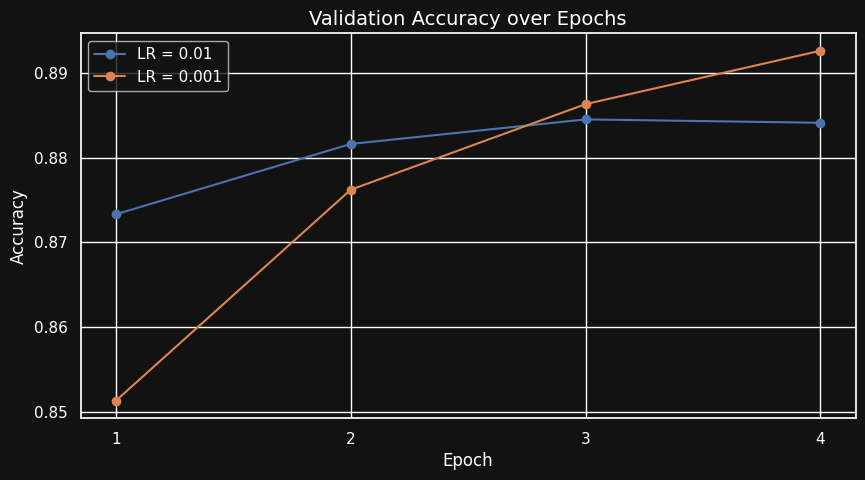

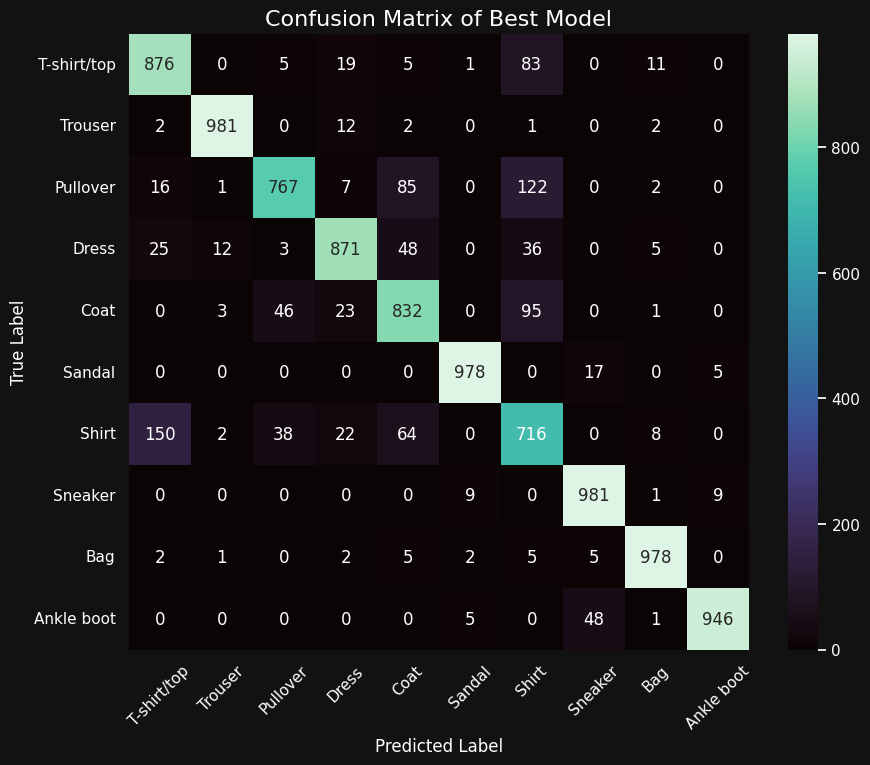


--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.88      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.89      0.77      0.83      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.80      0.83      0.82      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.68      0.72      0.70      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [4]:
# ==========================================
# 3. PRELIMINARY RESULTS (VISUALIZATIONS)
# ==========================================

# Slide 5: Hyperparameter Tuning Results
print("\n--- Summary of Hyperparameter Tuning ---")
df_results = pd.DataFrame([{'Learning Rate': r['LR'], 'Validation Accuracy': r['Final_Accuracy']} for r in tuning_results])
display(df_results)

# Plotting the Training Curves
plt.figure(figsize=(10, 5))
for res in tuning_results:
    plt.plot(res['History']['val_acc'], marker='o', label=f"LR = {res['LR']}")
plt.title('Validation Accuracy over Epochs', color='white', fontsize=14)
plt.xlabel('Epoch', color='white')
plt.ylabel('Accuracy', color='white')
plt.xticks(range(4), [1, 2, 3, 4])
plt.legend()
plt.show()

# Slide 6 & 7: Error Analysis (Confusion Matrix)
def evaluate_best_model(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    # Using a cool blue/purple colormap that fits the dark theme perfectly
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix of Best Model', color='white', fontsize=16)
    plt.xlabel('Predicted Label', color='white')
    plt.ylabel('True Label', color='white')
    plt.xticks(rotation=45)
    plt.show()

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

evaluate_best_model(best_model)

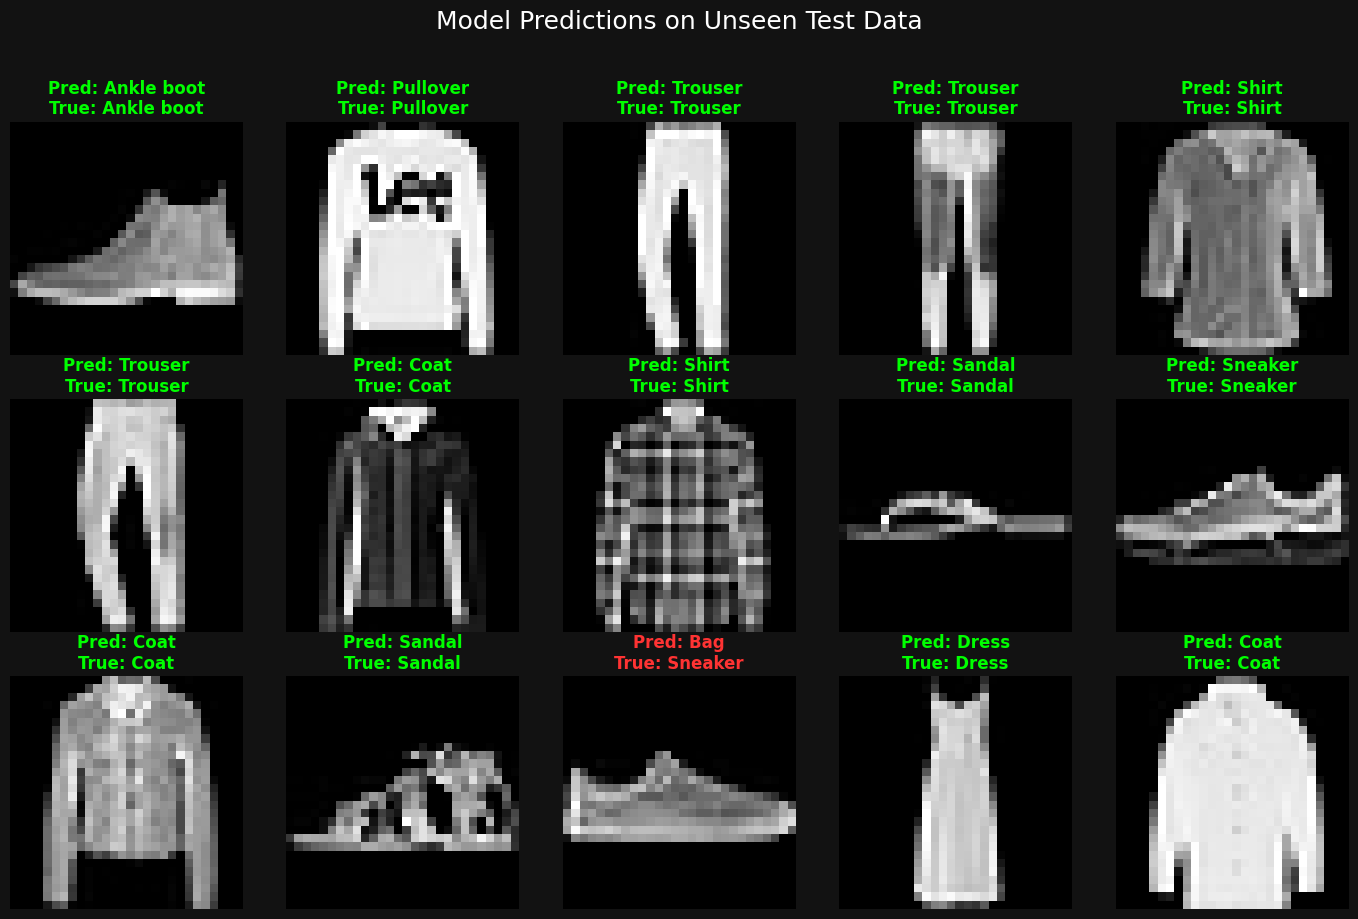


--- Batch Test Results ---
Correct Predictions: 56 / 64
Batch Accuracy: 87.50%


In [5]:
# ==========================================
# 4. FINAL TESTING & VISUAL INFERENCE
# ==========================================

def test_and_visualize(model, test_loader, num_images=15):
    # Grab a single batch of unseen test images
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images_device, labels_device = images.to(device), labels.to(device)

    # Set model to evaluation mode and get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

    # Move data back to CPU for plotting
    images = images.cpu()
    predicted = predicted.cpu()
    labels = labels.cpu()

    # Set up the visualization
    fig, axes = plt.subplots(3, 5, figsize=(14, 9))
    fig.suptitle('Model Predictions on Unseen Test Data', fontsize=18, color='white', y=1.02)

    for i, ax in enumerate(axes.flat):
        if i >= num_images:
            break

        img = images[i].numpy().squeeze()
        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]

        # Color coding: Neon Green for Correct, Bright Red for Incorrect
        text_color = '#00FF00' if true_label == pred_label else '#FF3333'

        ax.imshow(img, cmap='gray')
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=text_color, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and print the accuracy for this specific sample batch
    correct = (predicted == labels).sum().item()
    total = len(labels)
    print(f"\n--- Batch Test Results ---")
    print(f"Correct Predictions: {correct} / {total}")
    print(f"Batch Accuracy: {(correct/total)*100:.2f}%")

# Run the test using your best_model from the previous cell
test_and_visualize(best_model, val_loader)